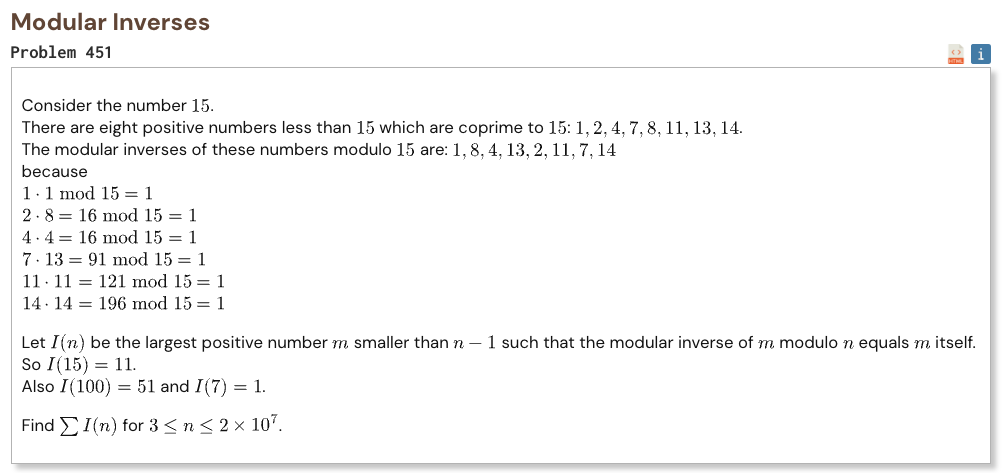

## Initial approach

-   being its own modular inverse means the number squared leaves remainder one
-   factor each number into prime powers using a smallest prime factor sieve
-   find the possible square roots of one for every prime power
-   odd prime powers have two possibilities while powers of two need special handling
-   combine the local possibilities with the chinese remainder theorem
-   ignore the always valid value one below the modulus and keep the next largest solution
-   add this value for every number up to twenty million
-   use array to store the sieve more compactly in memory

In [1]:
%%time

from array import array

N = 20_000_000

spf = array("I", [0]) * (N + 1)

for i in range(2, N + 1):
    if spf[i] == 0:
        spf[i] = i

        if i * i <= N:
            for j in range(i * i, N + 1, i):
                if spf[j] == 0:
                    spf[j] = i

def prime_powers(n):
    powers = []

    while n > 1:
        p = spf[n]
        q = 1

        while n % p == 0:
            q *= p
            n //= p

        powers.append(q)

    return powers

def local_roots(q):
    if q == 2:
        return [1]

    if q == 4:
        return [1, 3]

    if q % 2 == 0:
        half = q // 2
        return [1, q - 1, half - 1, half + 1]

    return [1, q - 1]

def self_inverse_values(n):
    factors = prime_powers(n)

    values = [0]
    modulus = 1

    for q in factors:
        roots = local_roots(q)
        inverse = pow(modulus, -1, q)

        new_values = []

        for a in values:
            for b in roots:
                t = ((b - a) * inverse) % q
                new_values.append(a + modulus * t)

        values = new_values
        modulus *= q

    return values

def I(n):
    values = self_inverse_values(n)

    best = 1

    for value in values:
        if value < n - 1 and value > best:
            best = value

    return best

result = 0

for n in range(3, N + 1):
    result += I(n)

print("Result:", result)

Result: 153651073760956
CPU times: user 1min 5s, sys: 297 ms, total: 1min 5s
Wall time: 1min 6s
